# Predictive Analysis of Movie Popularity

This notebook performs a lecture-aligned predictive analysis after the descriptive and inferential stages.

The predictive target is `log_box_office`, and the goal is to minimize prediction error while preserving interpretability.

This is a **predictive analysis**, not a causal analysis.

## 1. Predictive Goal and Response Definition

**Response variable:** `log_box_office`

**Predictive goal:** Build and compare explainable regression models that predict movie popularity on unseen data.

**Lecture alignment:** The notebook follows the regression and model-selection workflow from the course by using train/test evaluation, cross-validation, adjusted `R^2`, AIC, BIC, and subset-selection comparisons.

**Important restriction:** Leakage variables `boxOffice` and `box_office_num` are kept only for interpretation and error review, not as predictors.

## 2. Setup and Load Data

In [3]:
from pathlib import Path
import itertools
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore', category=RuntimeWarning)

TARGET = 'log_box_office'
TRAIN_SIZE = 0.80
TEST_SIZE = 0.20
RANDOM_STATE = 42
N_SPLITS = 5

CANDIDATE_PREDICTORS = [
    'audienceScore',
    'tomatoMeter',
    'runtimeMinutes',
    'initial_top_critic_review_count',
    'initial_positive_review_ratio',
    'initial_combined_sentiment_score',
    'log_initial_review_count',
    'initial_sentiment_x_log_review_count',
]

INFERENTIAL_MODEL_PREDICTORS = [
    'audienceScore',
    'initial_combined_sentiment_score',
    'log_initial_review_count',
    'initial_sentiment_x_log_review_count',
]


def resolve_data_path() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for base in candidates:
        candidate = base / 'data' / 'final' / 'final.csv'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find data/final/final.csv from the current working directory.')


DATA_PATH = resolve_data_path()
df = pd.read_csv(DATA_PATH)

print(f'Data path: {DATA_PATH}')
print(f'Raw dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')

Data path: c:\Users\dinuka\Documents\movie sentiment\data\final\final.csv
Raw dataset shape: 4,072 rows x 29 columns


## 3. Data Preparation for Prediction

The predictive frame keeps the target, identifiers for error review, and the selected explanatory variables. Leakage columns are excluded from the predictor matrix.

In [4]:
required_columns = ['id', 'title', 'box_office_num', TARGET, *CANDIDATE_PREDICTORS]
missing_required = [column for column in required_columns if column not in df.columns]
if missing_required:
    raise KeyError(f'Missing required columns: {missing_required}')

predictive_df = df[required_columns].copy()
for column in ['box_office_num', TARGET, *CANDIDATE_PREDICTORS]:
    predictive_df[column] = pd.to_numeric(predictive_df[column], errors='coerce')

predictive_df = predictive_df.dropna(subset=[TARGET, *CANDIDATE_PREDICTORS]).copy()
predictive_df = predictive_df[np.isfinite(predictive_df[TARGET])].copy()

data_quality_summary = pd.DataFrame({
    'non_null_count': predictive_df[['box_office_num', TARGET, *CANDIDATE_PREDICTORS]].notna().sum(),
    'mean': predictive_df[['box_office_num', TARGET, *CANDIDATE_PREDICTORS]].mean(),
    'std': predictive_df[['box_office_num', TARGET, *CANDIDATE_PREDICTORS]].std(),
}).sort_index()

print(f'Rows retained for predictive modeling: {predictive_df.shape[0]:,}')
display(data_quality_summary)
display(predictive_df[[TARGET, *CANDIDATE_PREDICTORS]].describe().T)

print('Leakage check:')
print("'boxOffice' used as predictor:", 'boxOffice' in CANDIDATE_PREDICTORS)
print("'box_office_num' used as predictor:", 'box_office_num' in CANDIDATE_PREDICTORS)

Rows retained for predictive modeling: 3,746


,non_null_count,mean,std
audienceScore,3746,61.5464,19.0213
box_office_num,3746,"47,814,753.9989","76,635,594.9357"
initial_combined_sentiment_score,3746,0.0902,0.5684
initial_positive_review_ratio,3746,0.5486,0.2832
initial_sentiment_x_log_review_count,3746,0.3433,2.2042
initial_top_critic_review_count,3746,16.2995,7.0257
log_box_office,3746,7.0873,0.9562
log_initial_review_count,3746,3.9113,0.4741
runtimeMinutes,3746,107.6164,17.3727
tomatoMeter,3746,55.7747,27.5591


,count,mean,std,min,25%,50%,75%,max
log_box_office,"3,746.0000",7.0873,0.9562,0.3010,6.5798,7.3324,7.7612,8.9337
audienceScore,"3,746.0000",61.5464,19.0213,10.0000,47.0000,62.0000,77.0000,99.0000
tomatoMeter,"3,746.0000",55.7747,27.5591,0.0000,32.0000,58.0000,81.0000,100.0000
runtimeMinutes,"3,746.0000",107.6164,17.3727,35.0000,95.0000,105.0000,117.0000,223.0000
initial_top_critic_review_count,"3,746.0000",16.2995,7.0257,0.0000,11.0000,16.0000,21.0000,61.0000
initial_positive_review_ratio,"3,746.0000",0.5486,0.2832,0.0000,0.3043,0.5671,0.8000,1.0000
initial_combined_sentiment_score,"3,746.0000",0.0902,0.5684,-1.0000,-0.4038,0.1215,0.5928,1.0000
log_initial_review_count,"3,746.0000",3.9113,0.4741,3.0910,3.5264,3.9120,4.2767,5.2627
initial_sentiment_x_log_review_count,"3,746.0000",0.3433,2.2042,-4.1744,-1.5698,0.4755,2.3097,4.8481


Leakage check:
'boxOffice' used as predictor: False
'box_office_num' used as predictor: False


## 4. Train/Test Split and Evaluation Setup

The predictive workflow uses a fixed train/test split for reproducibility and 5-fold cross-validation on the training set for model comparison.

In [5]:
X = predictive_df[CANDIDATE_PREDICTORS].copy()
y = predictive_df[TARGET].copy()

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    predictive_df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_df = predictive_df.loc[train_idx].copy()
test_df = predictive_df.loc[test_idx].copy()
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

split_summary = pd.DataFrame([
    {'set': 'train', 'rows': len(train_df), 'pct': len(train_df) / len(predictive_df) * 100},
    {'set': 'test', 'rows': len(test_df), 'pct': len(test_df) / len(predictive_df) * 100},
])
display(split_summary)

print(f'Random state: {RANDOM_STATE}')
print(f'CV folds: {N_SPLITS}')
print('Cross-validation is performed only on the training set.')


def evaluate_predictions(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {'rmse': rmse, 'mae': mae, 'r2': r2}


def cv_rmse_for_columns(columns: list[str]) -> float:
    model = LinearRegression()
    scores = cross_val_score(
        model,
        X_train[columns],
        y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error',
    )
    return float(-scores.mean())


def fit_statsmodels_ols(train_frame: pd.DataFrame, columns: list[str]):
    train_X = sm.add_constant(train_frame[columns], has_constant='add')
    return sm.OLS(train_frame[TARGET], train_X).fit()


def evaluate_linear_model(name: str, columns: list[str]) -> tuple[dict, sm.regression.linear_model.RegressionResultsWrapper, np.ndarray, np.ndarray]:
    fitted = fit_statsmodels_ols(train_df, columns)
    train_pred = fitted.predict(sm.add_constant(train_df[columns], has_constant='add'))
    test_pred = fitted.predict(sm.add_constant(test_df[columns], has_constant='add'))
    train_metrics = evaluate_predictions(train_df[TARGET], train_pred)
    test_metrics = evaluate_predictions(test_df[TARGET], test_pred)
    result = {
        'model': name,
        'n_features': len(columns),
        'features': ', '.join(columns),
        'adj_r_squared': float(fitted.rsquared_adj),
        'aic': float(fitted.aic),
        'bic': float(fitted.bic),
        'cv_rmse': cv_rmse_for_columns(columns),
        'train_rmse': train_metrics['rmse'],
        'train_mae': train_metrics['mae'],
        'train_r2': train_metrics['r2'],
        'test_rmse': test_metrics['rmse'],
        'test_mae': test_metrics['mae'],
        'test_r2': test_metrics['r2'],
    }
    return result, fitted, np.asarray(train_pred), np.asarray(test_pred)

,set,rows,pct
0,train,2996,79.9786
1,test,750,20.0214


Random state: 42
CV folds: 5
Cross-validation is performed only on the training set.


## 5. Baseline Predictive Models

The first comparison establishes baseline predictive performance before feature selection.

In [6]:
model_results = []
model_objects = {}
prediction_store = {}

baseline_mean = float(y_train.mean())
baseline_train_pred = np.full(len(y_train), baseline_mean)
baseline_test_pred = np.full(len(y_test), baseline_mean)
baseline_train_metrics = evaluate_predictions(y_train, baseline_train_pred)
baseline_test_metrics = evaluate_predictions(y_test, baseline_test_pred)
baseline_result = {
    'model': 'Baseline 0: Mean-only predictor',
    'n_features': 0,
    'features': 'intercept only',
    'adj_r_squared': np.nan,
    'aic': np.nan,
    'bic': np.nan,
    'cv_rmse': baseline_train_metrics['rmse'],
    'train_rmse': baseline_train_metrics['rmse'],
    'train_mae': baseline_train_metrics['mae'],
    'train_r2': baseline_train_metrics['r2'],
    'test_rmse': baseline_test_metrics['rmse'],
    'test_mae': baseline_test_metrics['mae'],
    'test_r2': baseline_test_metrics['r2'],
}
model_results.append(baseline_result)
prediction_store[baseline_result['model']] = {
    'train_pred': baseline_train_pred,
    'test_pred': baseline_test_pred,
    'features': [],
}

model_1_result, model_1_fit, model_1_train_pred, model_1_test_pred = evaluate_linear_model(
    'Model 1: Inferential four-variable regression',
    INFERENTIAL_MODEL_PREDICTORS,
)
model_results.append(model_1_result)
model_objects[model_1_result['model']] = model_1_fit
prediction_store[model_1_result['model']] = {
    'train_pred': model_1_train_pred,
    'test_pred': model_1_test_pred,
    'features': INFERENTIAL_MODEL_PREDICTORS,
}

model_2_result, model_2_fit, model_2_train_pred, model_2_test_pred = evaluate_linear_model(
    'Model 2: Full candidate-pool regression',
    CANDIDATE_PREDICTORS,
)
model_results.append(model_2_result)
model_objects[model_2_result['model']] = model_2_fit
prediction_store[model_2_result['model']] = {
    'train_pred': model_2_train_pred,
    'test_pred': model_2_test_pred,
    'features': CANDIDATE_PREDICTORS,
}

baseline_models_table = pd.DataFrame(model_results)
display(baseline_models_table)
print('Interpretation note: These first models show how much predictive accuracy improves beyond the mean-only benchmark and whether the current inferential model remains competitive for prediction.')

,model,n_features,features,adj_r_squared,aic,bic,cv_rmse,train_rmse,train_mae,train_r2,test_rmse,test_mae,test_r2
0,Baseline 0: Mean-only predictor,0,intercept only,NaN,NaN,NaN,0.9571,0.9571,0.7581,0.0000,0.9522,0.7515,-0.0018
1,Model 1: Inferential four-variable regression,4,"audienceScore, initial_combined_sentiment_scor...",0.4356,"6,531.9989","6,562.0241",0.7178,0.7186,0.5422,0.4363,0.7094,0.5362,0.4440
2,Model 2: Full candidate-pool regression,8,"audienceScore, tomatoMeter, runtimeMinutes, in...",0.4592,"6,408.1349","6,462.1802",0.7028,0.7029,0.5240,0.4606,0.7003,0.5240,0.4582


Interpretation note: These first models show how much predictive accuracy improves beyond the mean-only benchmark and whether the current inferential model remains competitive for prediction.


## 6. Feature Selection and Model Selection

This section applies the model-selection ideas from the feature-selection lecture by comparing adjusted `R^2`, AIC, BIC, and cross-validated RMSE.

In [7]:
subset_records = []
for size in range(1, len(CANDIDATE_PREDICTORS) + 1):
    for subset in itertools.combinations(CANDIDATE_PREDICTORS, size):
        fit = fit_statsmodels_ols(train_df, list(subset))
        subset_records.append({
            'method': 'Best subset',
            'n_features': size,
            'features': list(subset),
            'adj_r_squared': float(fit.rsquared_adj),
            'aic': float(fit.aic),
            'bic': float(fit.bic),
            'cv_rmse': cv_rmse_for_columns(list(subset)),
        })

best_subset_table = pd.DataFrame(subset_records)
best_subset_winners = (
    best_subset_table
    .sort_values(['cv_rmse', 'bic', 'n_features'])
    .groupby('n_features', as_index=False)
    .first()
    .sort_values('n_features')
)

display(best_subset_winners)
print(f'Total subsets evaluated: {len(best_subset_table):,}')

,n_features,method,features,adj_r_squared,aic,bic,cv_rmse
0,1,Best subset,[log_initial_review_count],0.3892,"6,765.4188","6,777.4288",0.7466
1,2,Best subset,"[tomatoMeter, log_initial_review_count]",0.4085,"6,670.3082","6,688.3233",0.7346
2,3,Best subset,"[audienceScore, tomatoMeter, log_initial_revie...",0.4370,"6,523.5689","6,547.5890",0.7168
3,4,Best subset,"[audienceScore, tomatoMeter, initial_top_criti...",0.4515,"6,446.1214","6,476.1465",0.7072
4,5,Best subset,"[audienceScore, tomatoMeter, initial_top_criti...",0.4583,"6,409.7836","6,445.8138",0.7026
5,6,Best subset,"[audienceScore, tomatoMeter, initial_top_criti...",0.4593,"6,405.1108","6,447.1461",0.7021
6,7,Best subset,"[audienceScore, tomatoMeter, initial_top_criti...",0.4593,"6,406.1501","6,454.1904",0.7021
7,8,Best subset,"[audienceScore, tomatoMeter, runtimeMinutes, i...",0.4592,"6,408.1349","6,462.1802",0.7028


Total subsets evaluated: 255


In [8]:
remaining = CANDIDATE_PREDICTORS.copy()
selected = []
forward_records = []

while remaining:
    candidate_step_results = []
    for feature in remaining:
        trial_features = selected + [feature]
        fit = fit_statsmodels_ols(train_df, trial_features)
        candidate_step_results.append({
            'step': len(trial_features),
            'features': trial_features.copy(),
            'added_feature': feature,
            'adj_r_squared': float(fit.rsquared_adj),
            'aic': float(fit.aic),
            'bic': float(fit.bic),
            'cv_rmse': cv_rmse_for_columns(trial_features),
        })
    step_df = pd.DataFrame(candidate_step_results).sort_values(['cv_rmse', 'bic', 'step'])
    best_step = step_df.iloc[0].to_dict()
    forward_records.append(best_step)
    selected = best_step['features']
    remaining.remove(best_step['added_feature'])

forward_stepwise_table = pd.DataFrame(forward_records)
display(forward_stepwise_table)
print('Forward stepwise selection starts from the intercept-only model and adds one feature per step.')

,step,features,added_feature,adj_r_squared,aic,bic,cv_rmse
0,1,[log_initial_review_count],log_initial_review_count,0.3892,"6,765.4188","6,777.4288",0.7466
1,2,"[log_initial_review_count, tomatoMeter]",tomatoMeter,0.4085,"6,670.3082","6,688.3233",0.7346
2,3,"[log_initial_review_count, tomatoMeter, audien...",audienceScore,0.4370,"6,523.5689","6,547.5890",0.7168
3,4,"[log_initial_review_count, tomatoMeter, audien...",initial_top_critic_review_count,0.4515,"6,446.1214","6,476.1465",0.7072
4,5,"[log_initial_review_count, tomatoMeter, audien...",initial_sentiment_x_log_review_count,0.4583,"6,409.7836","6,445.8138",0.7026
5,6,"[log_initial_review_count, tomatoMeter, audien...",initial_combined_sentiment_score,0.4593,"6,405.1108","6,447.1461",0.7021
6,7,"[log_initial_review_count, tomatoMeter, audien...",initial_positive_review_ratio,0.4593,"6,406.1501","6,454.1904",0.7021
7,8,"[log_initial_review_count, tomatoMeter, audien...",runtimeMinutes,0.4592,"6,408.1349","6,462.1802",0.7028


Forward stepwise selection starts from the intercept-only model and adds one feature per step.


In [9]:
best_subset_choice = best_subset_table.sort_values(['cv_rmse', 'bic', 'n_features']).iloc[0]
forward_choice = forward_stepwise_table.sort_values(['cv_rmse', 'bic', 'step']).iloc[0]

best_subset_features = list(best_subset_choice['features'])
forward_features = list(forward_choice['features'])

model_3_result, model_3_fit, model_3_train_pred, model_3_test_pred = evaluate_linear_model(
    'Model 3: Best-subset selected regression',
    best_subset_features,
)
model_results.append(model_3_result)
model_objects[model_3_result['model']] = model_3_fit
prediction_store[model_3_result['model']] = {
    'train_pred': model_3_train_pred,
    'test_pred': model_3_test_pred,
    'features': best_subset_features,
}

model_4_result, model_4_fit, model_4_train_pred, model_4_test_pred = evaluate_linear_model(
    'Model 4: Forward-stepwise selected regression',
    forward_features,
)
model_results.append(model_4_result)
model_objects[model_4_result['model']] = model_4_fit
prediction_store[model_4_result['model']] = {
    'train_pred': model_4_train_pred,
    'test_pred': model_4_test_pred,
    'features': forward_features,
}

feature_selection_summary = pd.DataFrame([
    {
        'selection_method': 'Best subset winner',
        'features': ', '.join(best_subset_features),
        'n_features': len(best_subset_features),
        'adj_r_squared': model_3_result['adj_r_squared'],
        'aic': model_3_result['aic'],
        'bic': model_3_result['bic'],
        'cv_rmse': model_3_result['cv_rmse'],
    },
    {
        'selection_method': 'Forward stepwise winner',
        'features': ', '.join(forward_features),
        'n_features': len(forward_features),
        'adj_r_squared': model_4_result['adj_r_squared'],
        'aic': model_4_result['aic'],
        'bic': model_4_result['bic'],
        'cv_rmse': model_4_result['cv_rmse'],
    },
])
display(feature_selection_summary)

,selection_method,features,n_features,adj_r_squared,aic,bic,cv_rmse
0,Best subset winner,"audienceScore, tomatoMeter, initial_top_critic...",6,0.4593,"6,405.1108","6,447.1461",0.7021
1,Forward stepwise winner,"log_initial_review_count, tomatoMeter, audienc...",6,0.4593,"6,405.1108","6,447.1461",0.7021


## 7. Final Model Comparison

The final selected model is chosen by the declared rule: lowest cross-validated RMSE, then lower test RMSE, then lower BIC, then fewer features.

In [10]:
model_comparison_table = pd.DataFrame(model_results)
selection_ready_table = model_comparison_table.copy()
selection_ready_table['bic_for_sort'] = selection_ready_table['bic'].fillna(np.inf)
selection_ready_table = selection_ready_table.sort_values(
    ['cv_rmse', 'test_rmse', 'bic_for_sort', 'n_features'],
    ascending=[True, True, True, True],
)
final_model_name = selection_ready_table.iloc[0]['model']
final_model_features = prediction_store[final_model_name]['features']
final_model_fit = model_objects.get(final_model_name)

display(model_comparison_table.sort_values('cv_rmse'))
print(f'Final selected model: {final_model_name}')
print(f'Final selected features: {final_model_features}')

best_fit_model_name = model_comparison_table.sort_values('train_rmse').iloc[0]['model']
best_generalizing_model_name = model_comparison_table.sort_values('test_rmse').iloc[0]['model']
simplest_acceptable_model_name = selection_ready_table.iloc[0]['model']

selection_commentary = pd.DataFrame([
    {'category': 'Best training fit', 'model': best_fit_model_name},
    {'category': 'Best held-out test performance', 'model': best_generalizing_model_name},
    {'category': 'Selected final model', 'model': simplest_acceptable_model_name},
])
display(selection_commentary)

selected_row = model_comparison_table.loc[model_comparison_table['model'] == final_model_name].iloc[0]
cv_test_gap = float(selected_row['test_rmse'] - selected_row['cv_rmse'])
print(f'Overfitting check (test RMSE - CV RMSE): {cv_test_gap:.4f}')
if cv_test_gap > 0.05:
    print('Interpretation note: The selected model performs worse on the held-out test set than in training cross-validation, so overfitting risk should be discussed.')
else:
    print('Interpretation note: The selected model shows similar cross-validation and held-out test performance, so overfitting is not strongly indicated.')

,model,n_features,features,adj_r_squared,aic,bic,cv_rmse,train_rmse,train_mae,train_r2,test_rmse,test_mae,test_r2
3,Model 3: Best-subset selected regression,6,"audienceScore, tomatoMeter, initial_top_critic...",0.4593,"6,405.1108","6,447.1461",0.7021,0.7030,0.5240,0.4604,0.6990,0.5236,0.4603
4,Model 4: Forward-stepwise selected regression,6,"log_initial_review_count, tomatoMeter, audienc...",0.4593,"6,405.1108","6,447.1461",0.7021,0.7030,0.5240,0.4604,0.6990,0.5236,0.4603
2,Model 2: Full candidate-pool regression,8,"audienceScore, tomatoMeter, runtimeMinutes, in...",0.4592,"6,408.1349","6,462.1802",0.7028,0.7029,0.5240,0.4606,0.7003,0.5240,0.4582
1,Model 1: Inferential four-variable regression,4,"audienceScore, initial_combined_sentiment_scor...",0.4356,"6,531.9989","6,562.0241",0.7178,0.7186,0.5422,0.4363,0.7094,0.5362,0.4440
0,Baseline 0: Mean-only predictor,0,intercept only,NaN,NaN,NaN,0.9571,0.9571,0.7581,0.0000,0.9522,0.7515,-0.0018


Final selected model: Model 3: Best-subset selected regression
Final selected features: ['audienceScore', 'tomatoMeter', 'initial_top_critic_review_count', 'initial_combined_sentiment_score', 'log_initial_review_count', 'initial_sentiment_x_log_review_count']


,category,model
0,Best training fit,Model 2: Full candidate-pool regression
1,Best held-out test performance,Model 3: Best-subset selected regression
2,Selected final model,Model 3: Best-subset selected regression


Overfitting check (test RMSE - CV RMSE): -0.0031
Interpretation note: The selected model shows similar cross-validation and held-out test performance, so overfitting is not strongly indicated.


## 8. Prediction Diagnostics and Error Analysis

This section evaluates the selected model with prediction plots and identifies the movies with the largest absolute errors.

,id,title,box_office_num,log_box_office,predicted_log_box_office,residual,absolute_error,predicted_box_office_num,box_office_error
2416,a_glitch_in_the_matrix,A Glitch in the Matrix,"1,700.0000",3.2304,6.6043,-3.3738,3.3738,"4,020,273.2062","-4,018,573.2062"
1189,the_wicker_man_2006,The Wicker Man,"18,800.0000",4.2742,7.3314,-3.0572,3.0572,"21,446,957.5503","-21,428,157.5503"
2579,the_apparition,The Apparition,"26,800.0000",4.4281,7.0611,-2.6330,2.6330,"11,511,354.8452","-11,484,554.8452"
1728,summerland_2020,Summerland,"58,300.0000",4.7657,7.2664,-2.5007,2.5007,"18,465,357.0275","-18,407,057.0275"
3620,paranormal_activity,Paranormal Activity,"107,900,000.0000",8.0330,5.9896,2.0435,2.0435,"976,240.1834","106,923,759.8166"
3791,farewell_amor,Farewell Amor,"4,700.0000",3.6721,5.6621,-1.9900,1.9900,"459,315.5355","-454,615.5355"
3501,shithouse,S...house,"18,100.0000",4.2577,6.2364,-1.9788,1.9788,"1,723,569.7710","-1,705,469.7710"
2475,true_history_of_the_kelly_gang,True History of the Kelly Gang,"33,800.0000",4.5289,6.4642,-1.9353,1.9353,"2,911,949.7650","-2,878,149.7650"
3112,swallow,Swallow,"31,300.0000",4.4955,6.4164,-1.9208,1.9208,"2,608,289.3724","-2,576,989.3724"
3898,black_swan_2010,Black Swan,"107,000,000.0000",8.0294,6.1121,1.9173,1.9173,"1,294,375.4544","105,705,624.5456"


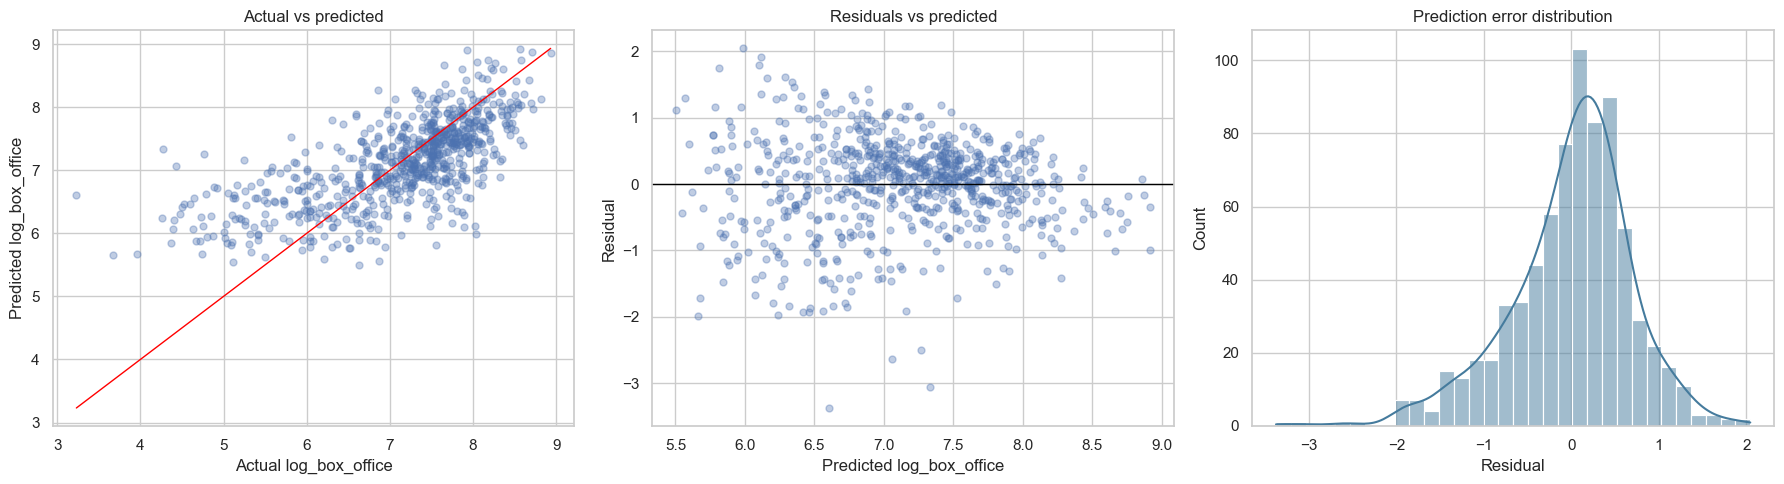

In [11]:
final_test_pred = prediction_store[final_model_name]['test_pred']
final_train_pred = prediction_store[final_model_name]['train_pred']

diagnostic_frame = test_df[['id', 'title', 'box_office_num', TARGET]].copy()
diagnostic_frame['predicted_log_box_office'] = final_test_pred
diagnostic_frame['residual'] = diagnostic_frame[TARGET] - diagnostic_frame['predicted_log_box_office']
diagnostic_frame['absolute_error'] = diagnostic_frame['residual'].abs()
diagnostic_frame['predicted_box_office_num'] = np.power(10, diagnostic_frame['predicted_log_box_office'])
diagnostic_frame['box_office_error'] = diagnostic_frame['box_office_num'] - diagnostic_frame['predicted_box_office_num']

largest_error_table = diagnostic_frame.sort_values('absolute_error', ascending=False).head(15)
display(largest_error_table)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(diagnostic_frame[TARGET], diagnostic_frame['predicted_log_box_office'], alpha=0.35, s=25)
line_min = min(diagnostic_frame[TARGET].min(), diagnostic_frame['predicted_log_box_office'].min())
line_max = max(diagnostic_frame[TARGET].max(), diagnostic_frame['predicted_log_box_office'].max())
axes[0].plot([line_min, line_max], [line_min, line_max], color='red', linewidth=1)
axes[0].set_title('Actual vs predicted')
axes[0].set_xlabel('Actual log_box_office')
axes[0].set_ylabel('Predicted log_box_office')

axes[1].scatter(diagnostic_frame['predicted_log_box_office'], diagnostic_frame['residual'], alpha=0.35, s=25)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Residuals vs predicted')
axes[1].set_xlabel('Predicted log_box_office')
axes[1].set_ylabel('Residual')

sns.histplot(diagnostic_frame['residual'], kde=True, ax=axes[2], color='#457b9d')
axes[2].set_title('Prediction error distribution')
axes[2].set_xlabel('Residual')

plt.tight_layout()
plt.show()

In [12]:
back_transformed_examples = diagnostic_frame[
    ['id', 'title', 'box_office_num', 'predicted_box_office_num', 'box_office_error', 'absolute_error']
].sort_values('absolute_error').head(10)
display(back_transformed_examples)
print('Interpretation note: Back-transformed box-office values are shown only to make predictions easier to read. Model selection is still based on prediction error for log_box_office.')

,id,title,box_office_num,predicted_box_office_num,box_office_error,absolute_error
869,house_of_wax_2005,House of Wax,"32,000,000.0000","31,989,078.3463","10,921.6537",0.0001
3354,marley,Marley,"1,400,000.0000","1,396,933.4223","3,066.5777",0.0010
307,real_steel,Real Steel,"85,500,000.0000","84,898,185.6857","601,814.3143",0.0031
2916,thoroughbreds_2018,Thoroughbreds,"2,700,000.0000","2,738,484.8814","-38,484.8814",0.0061
1543,the_prince_and_me,The Prince & Me,"28,200,000.0000","27,740,882.0465","459,117.9535",0.0071
187,kong_skull_island,Kong: Skull Island,"168,000,000.0000","165,192,199.3345","2,807,800.6655",0.0073
3031,material_girls,Material Girls,"11,400,000.0000","11,617,837.8078","-217,837.8078",0.0082
226,terminator_4,Terminator Salvation,"125,300,000.0000","122,873,037.8302","2,426,962.1698",0.0085
3828,harry_brown,Harry Brown,"1,800,000.0000","1,763,450.5976","36,549.4024",0.0089
1270,johnson_family_vacation,Johnson Family Vacation,"31,200,000.0000","31,869,164.5800","-669,164.5800",0.0092


Interpretation note: Back-transformed box-office values are shown only to make predictions easier to read. Model selection is still based on prediction error for log_box_office.


## 9. Feature Contribution View for the Final Model

Because the selected model is linear, a standardized-coefficient view can be used as an interpretable contribution summary.

In [13]:
if final_model_features:
    standardized_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression()),
    ])
    standardized_pipeline.fit(train_df[final_model_features], train_df[TARGET])
    standardized_coefs = standardized_pipeline.named_steps['regressor'].coef_
    contribution_table = pd.DataFrame({
        'feature': final_model_features,
        'standardized_coef': standardized_coefs,
        'absolute_standardized_coef': np.abs(standardized_coefs),
    }).sort_values('absolute_standardized_coef', ascending=False)
    display(contribution_table)
else:
    print('No feature contribution table is available for the intercept-only model.')

,feature,standardized_coef,absolute_standardized_coef
4,log_initial_review_count,0.6472,0.6472
5,initial_sentiment_x_log_review_count,0.6142,0.6142
1,tomatoMeter,-0.5702,0.5702
3,initial_combined_sentiment_score,-0.3222,0.3222
0,audienceScore,0.2022,0.2022
2,initial_top_critic_review_count,-0.1504,0.1504


## 10. Final Predictive Conclusion

In [14]:
final_row = model_comparison_table.loc[model_comparison_table['model'] == final_model_name].iloc[0]
print('Predictive conclusion')
print(f"Selected model: {final_model_name}")
print(f"Number of predictors: {int(final_row['n_features'])}")
print(f"Cross-validated RMSE: {final_row['cv_rmse']:.4f}")
print(f"Test RMSE: {final_row['test_rmse']:.4f}")
print(f"Test MAE: {final_row['test_mae']:.4f}")
print(f"Test R-squared: {final_row['test_r2']:.4f}")
print('\nLecture-aligned interpretation:')
print('- The final model was selected primarily by cross-validated RMSE on the training set.')
print('- Test-set metrics were used to confirm generalization to unseen observations.')
print('- Adjusted R-squared, AIC, and BIC were used as supporting model-selection criteria.')
print('- The chosen model balances predictive accuracy and interpretability better than the benchmark alternatives.')
print('- This result should be interpreted as predictive usefulness, not causal proof.')
print(f"- Best training fit model: {best_fit_model_name}")
print(f"- Best held-out test model: {best_generalizing_model_name}")
print(f"- Simplest acceptable selected model: {simplest_acceptable_model_name}")

Predictive conclusion
Selected model: Model 3: Best-subset selected regression
Number of predictors: 6
Cross-validated RMSE: 0.7021
Test RMSE: 0.6990
Test MAE: 0.5236
Test R-squared: 0.4603

Lecture-aligned interpretation:
- The final model was selected primarily by cross-validated RMSE on the training set.
- Test-set metrics were used to confirm generalization to unseen observations.
- Adjusted R-squared, AIC, and BIC were used as supporting model-selection criteria.
- The chosen model balances predictive accuracy and interpretability better than the benchmark alternatives.
- This result should be interpreted as predictive usefulness, not causal proof.
- Best training fit model: Model 2: Full candidate-pool regression
- Best held-out test model: Model 3: Best-subset selected regression
- Simplest acceptable selected model: Model 3: Best-subset selected regression
